In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import sys
import glob
import random
import os
import json
from ultralytics import YOLO

# Add src to path to import pipeline functions if needed
sys.path.append("../src")
from main_pipeline import load_models

# Visual settings
%matplotlib inline
plt.rcParams['figure.figsize'] = [20, 10]

print("Environment Ready.")


Environment Ready.


In [2]:
# Manually define paths to ensure we are using the right ones
MODEL_PATHS = {
    "stage3": "../models/stage3_final_v2/weights/best.pt",
    "stage1": "../models/stage1_n_640/train/weights/best.pt",
    "stage2": "../models/stage2_m_640_upgrade/weights/best.pt"
}

models = {}
for key, path in MODEL_PATHS.items():
    if os.path.exists(path):
        print(f"Loading {key}: {path}")
        models[key] = YOLO(path)
    else:
        print(f"MISSING: {path}")

print("Models Loaded.")


Loading stage3: ../models/stage3_final_v2/weights/best.pt
Loading stage1: ../models/stage1_n_640/train/weights/best.pt
Loading stage2: ../models/stage2_m_640_upgrade/weights/best.pt
Models Loaded.


Selected Image: ../data/raw/test/disease/input/test_145.png


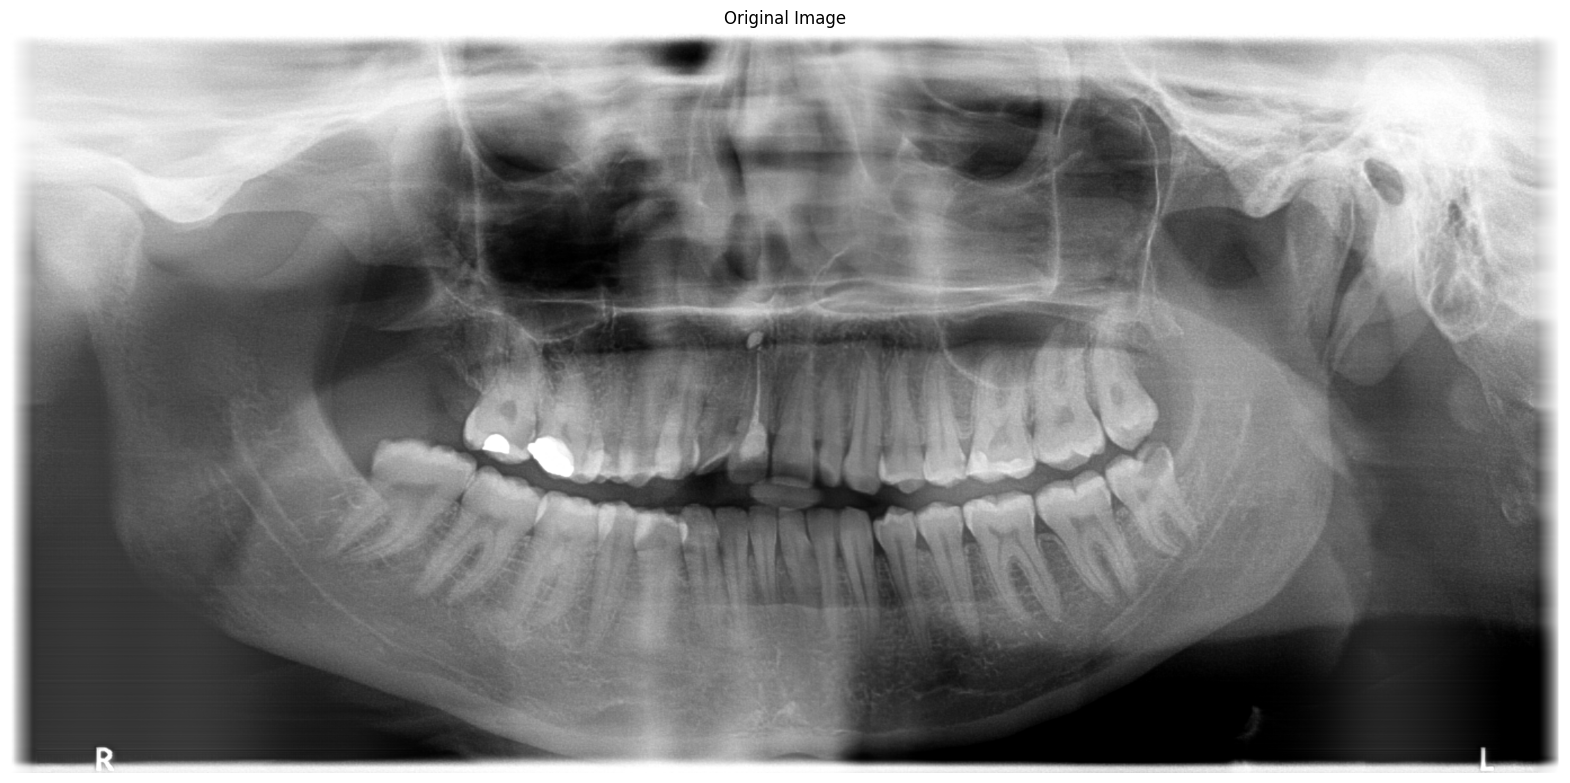

In [3]:
# Select a random validation image
val_images = glob.glob('../data/raw/test/disease/input/*.png')
if not val_images:
    print("No images found! Check path.")
else:
    # You can set a specific seed or hardcode an index for reproducibility if needed
    # img_path = "../data/raw/val/validation_data/quadrant_enumeration_disease/xrays/val_1.png" # Uncomment to force val_1
    img_path = random.choice(val_images)
    print(f"Selected Image: {img_path}")

    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    plt.imshow(img_rgb)
    plt.title("Original Image")
    plt.axis('off')
    plt.show()


Stage 1 found 4 quadrants.


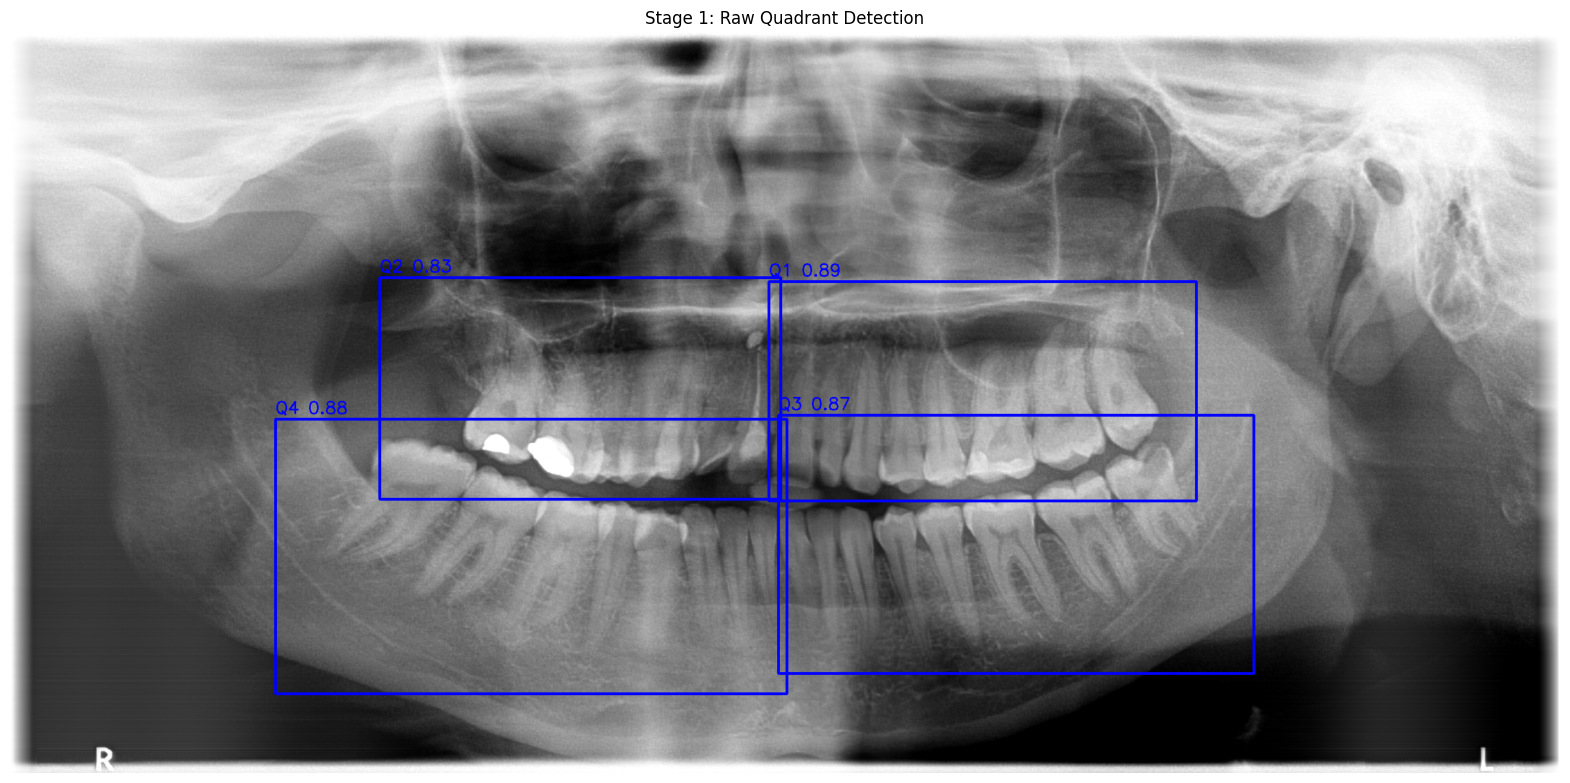

Quadrant Q1: [1347, 444, 2106, 833]
Quadrant Q4: [471, 688, 1379, 1175]
Quadrant Q3: [1364, 681, 2208, 1139]
Quadrant Q2: [656, 437, 1368, 830]


In [4]:
# --- TEST 1: Quadrant Detection (Is the model finding them?) ---
s1_results = models['stage1'].predict(img, conf=0.6, verbose=False)[0]
q_boxes = s1_results.boxes

print(f"Stage 1 found {len(q_boxes)} quadrants.")

img_q = img_rgb.copy()
detected_quadrants = []

for box in q_boxes:
    x1, y1, x2, y2 = map(int, box.xyxy[0].cpu().numpy())
    conf = box.conf[0].item()
    cls_id = int(box.cls[0].item())
    label = s1_results.names[cls_id]
    
    # Store for later logic testing
    detected_quadrants.append({'label': label, 'bbox': [x1, y1, x2, y2]})
    
    # Visualization
    cv2.rectangle(img_q, (x1, y1), (x2, y2), (0, 0, 255), 3) # Blue boxes (RGB for MPL is Red)
    cv2.putText(img_q, f"{label} {conf:.2f}", (x1, y1-10), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2)

plt.imshow(img_q)
plt.title("Stage 1: Raw Quadrant Detection")
plt.axis('off')
plt.show()

for q in detected_quadrants:
    print(f"Quadrant {q['label']}: {q['bbox']}")


Running Stage 1 to locate quadrants...
Stage 1 found 4 quadrants.
Stage 2 found 31 total teeth.


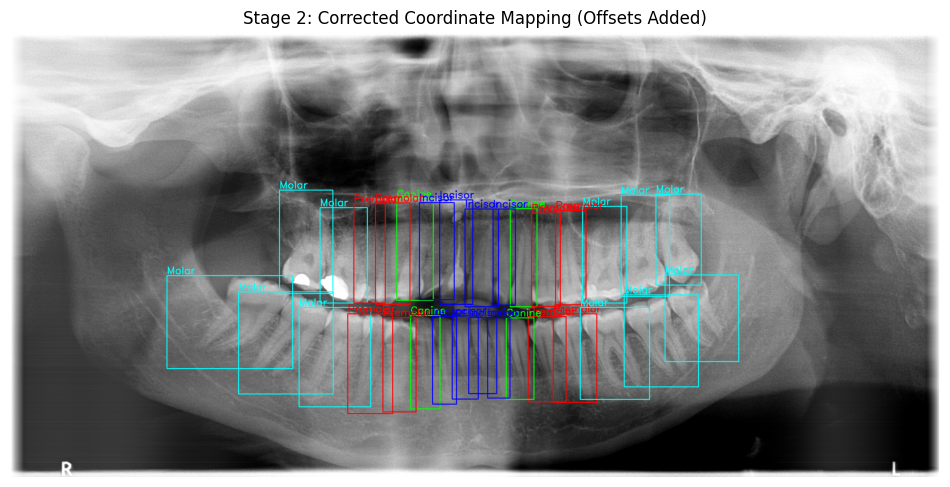

In [5]:
# --- TEST 2: Tooth Detection (Is the model finding the upper teeth?) ---
# [FIXED] Correct Logic: Stage 2 expects QUADRANT CROPS, not the full image.

# 1. Run Stage 1 to find quadrants (in case not run or context lost)
print("Running Stage 1 to locate quadrants...")

COLORS = {
    0 : (255, 0, 0),   # Red
    1 : (0, 255, 0),   # Green
    2 : (0, 0, 255),   # Blue
    3 : (255, 255, 0)  # Yellow
}

s1_results = models['stage1'].predict(img, conf=0.25, verbose=False)[0]

quadrants = []
for box in s1_results.boxes:
    coords = list(map(int, box.xyxy[0].cpu().numpy()))
    cls_id = int(box.cls[0])
    label = s1_results.names[cls_id]
    quadrants.append((label, coords))

print(f"Stage 1 found {len(quadrants)} quadrants.")

img_t = img.copy() # Visualization Image
h_img, w_img = img.shape[:2]
detected_teeth = []

# 2. Iterate Quadrants, Crop, Predict
for q_label, q_box in quadrants:
    qx1, qy1, qx2, qy2 = q_box
    
    # 10% Padding (Match training)
    q_w = qx2 - qx1
    q_h = qy2 - qy1
    pad_x = int(q_w * 0.10)
    pad_y = int(q_h * 0.10)
    
    crop_x1 = max(0, qx1 - pad_x)
    crop_y1 = max(0, qy1 - pad_y)
    crop_x2 = min(w_img, qx2 + pad_x)
    crop_y2 = min(h_img, qy2 + pad_y)
    
    q_crop = img[crop_y1:crop_y2, crop_x1:crop_x2]
    if q_crop.size == 0: continue

    # Stage 2 Prediction on CROP
    s2_results = models['stage2'].predict(q_crop, conf=0.4, verbose=False)[0]
    
    
    # 3. Map Coordinates & Visualize
    for t_box in s2_results.boxes:
        cx1, cy1, cx2, cy2 = map(int, t_box.xyxy[0].cpu().numpy())
        conf = t_box.conf[0].item()
        cls_id = int(t_box.cls[0].item())
        cls_name = s2_results.names[cls_id] if s2_results.names else str(cls_id)
        
        # --- CRITICAL FIX: Add Crop Offset ---
        gx1 = cx1 + crop_x1
        gy1 = cy1 + crop_y1
        gx2 = cx2 + crop_x1
        gy2 = cy2 + crop_y1
        
        detected_teeth.append({'label': cls_name, 'bbox': [gx1, gy1, gx2, gy2], 'conf': conf})
        color = COLORS.get(cls_id, (255, 255, 255))
        
        # Draw Tooth (Green)
        cv2.rectangle(img_t, (gx1, gy1), (gx2, gy2), color, 2)
        # Add text
        cv2.putText(img_t, cls_name, (gx1, gy1-5), cv2.FONT_HERSHEY_SIMPLEX, 1, color, 2)

print(f"Stage 2 found {len(detected_teeth)} total teeth.")

plt.figure(figsize=(12, 8))
plt.imshow(cv2.cvtColor(img_t, cv2.COLOR_BGR2RGB))
plt.title(f"Stage 2: Corrected Coordinate Mapping (Offsets Added)")
plt.axis('off')
plt.show()



--- Stage 3: Disease Classification (Class-wise) ---
Analyzing 31 teeth...
Found 0 suspicious teeth (excluding Healthy).


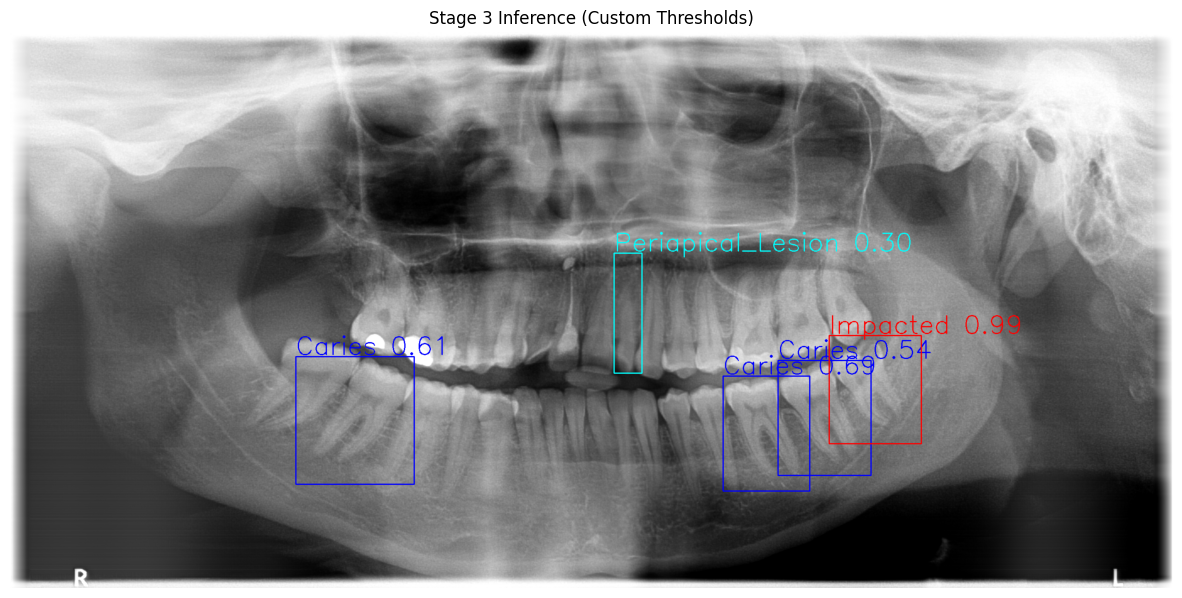

In [6]:

# --- Stage 3: Disease Classification (Class-wise Thresholds) ---

# Sınıf bazlı thresholdlar
THRESHOLDS = {
    "Periapical_Lesion": 0.20,  # %20 şüphe bile yeterli!
    "Deep_Caries": 0.30,        # %30
    "Caries": 0.45,             # %45
    "Impacted": 0.60         # %60
}

print("\n--- Stage 3: Disease Classification (Class-wise) ---")

if "stage3" not in models:
    print("Error: Stage 3 model not loaded!")
else:
    # 1. Image Reload (Clean Copy)
    # img_path should be defined in previous cells
    img_clean = cv2.imread(img_path)
    if img_clean is None: 
        print(f"Error: Could not load {img_path}")
    else:
        # Working Copy
        final_img = img_clean.copy()
        h_img, w_img = final_img.shape[:2]
        
        # Colors (BGR for cv2)
        COLORS = {
            "Caries": (255, 0, 0),       
            "Deep_Caries": (0, 255, 0),   
            "Impacted": (0, 0, 255),      
            "Periapical_Lesion": (255, 255, 0)
        }
        
        count_disease = 0
        
        # Check if detected_teeth exists
        if 'detected_teeth' not in locals():
            print("Warning: 'detected_teeth' not found. Please run Stage 2 cells first.")
            detected_teeth = []

        print(f"Analyzing {len(detected_teeth)} teeth...")
        
        for tooth in detected_teeth:
            tx1, ty1, tx2, ty2 = tooth['bbox']
            
            # Padding Constraints
            tx1, ty1 = max(0, tx1), max(0, ty1)
            tx2, ty2 = min(w_img, tx2), min(h_img, ty2)
            
            t_crop = img_clean[ty1:ty2, tx1:tx2]
            if t_crop.size == 0: continue
            
            # Predict S3
            res = models["stage3"].predict(t_crop, verbose=False)
            
            probs = res[0].probs
            top1_id = probs.top1
            top1_conf = probs.top1conf.item()
            top1_name = res[0].names[top1_id]
            
            # Threshold Check
            required_conf = THRESHOLDS.get(top1_name, 0.5)
            
            if top1_conf >= required_conf and top1_name!="Healthy":
                # Accepted Prediction
                
                # Draw Box
                color = COLORS.get(top1_name, (200, 200, 200))
                
                # If Healthy, maybe skip drawing or draw thin
                thickness = 2
                    
                cv2.rectangle(final_img, (tx1, ty1), (tx2, ty2), color, thickness)
                
                # Label
                label_txt = f"{top1_name} {top1_conf:.2f}"
                cv2.putText(final_img, label_txt, (tx1, ty1-5), cv2.FONT_HERSHEY_SIMPLEX, 2, color, thickness)
                
            else:
                # Low Confidence - Treated as Unknown/Skipped
                pass

        print(f"Found {count_disease} suspicious teeth (excluding Healthy).")

        # Show Result
        plt.figure(figsize=(15, 10))
        plt.imshow(cv2.cvtColor(final_img, cv2.COLOR_BGR2RGB))
        plt.title(f"Stage 3 Inference (Custom Thresholds)")
        plt.axis('off')
        plt.show()


Healthy
